# Imports

In [1]:
import time
import numpy as np
import math
import mujoco
import mujoco.viewer

import mediapy as media
import matplotlib.pyplot as plt

from robotblockset.tools import get_rbs_path

from IPython.display import clear_output

clear_output()

import genesis as gs
from robotblockset.genesis.robots_genesis import ur10e

from robotblockset.transformations import map_pose, rot_x, rot_y, rot_z, rp2t, xerr
from robotblockset.optimal import path_constraints, path_kinematics, timeopt_joint_traj

np.set_printoptions(precision=3, suppress=True, linewidth=100)

# Initialization

In [2]:
it = 0
def CaptureRobot_gen(r):
    global it, tt, twall, trob, qt, rqt, qdt, rqdt, xt, vt, rxt, rvt, mt, xtf, vtf, frames
    if it == 0:
        tt = np.array(r.t)
        twall = time.time()
        trob = r._robottime
        qt = r._actual.q
        qdt = r._actual.qdot
        rqt = r._command.q
        rqdt = r._command.qdot
        xt = r._actual.x
        vt = r._actual.v
        rxt = r._command.x
        rvt = r._command.v
        mt = r._command.mode
        xtf = gs.utils.tensor_to_array(r.robot_entity.links[-1].get_pos())
        vtf = gs.utils.tensor_to_array(r.robot_entity.links[-1].get_vel())
    else:
        tt = np.vstack((tt, r.t))
        twall = np.vstack((twall, time.time()))
        trob = np.vstack((trob, r._robottime))
        qt = np.vstack((qt, r._actual.q))
        qdt = np.vstack((qdt, r._actual.qdot))
        rqt = np.vstack((rqt, r._command.q))
        rqdt = np.vstack((rqdt, r._command.qdot))
        xt = np.vstack((xt, r._actual.x))
        vt = np.vstack((vt, r._actual.v))
        rxt = np.vstack((rxt, r._command.x))
        rvt = np.vstack((rvt, r._command.v))
        mt = np.vstack((mt, r._command.mode))
        xtf = np.vstack((xtf, gs.utils.tensor_to_array(r.robot_entity.links[-1].get_pos())))
        vtf = np.vstack((vtf, gs.utils.tensor_to_array(r.robot_entity.links[-1].get_vel())))
    frames.append(r.cam.render()[0])
    it += 1

In [3]:
SCENE_PATH = get_rbs_path() + "/mujoco/mjcf_models/inspection_scene.xml"
SHOW_VIEWER = True

# Generation of Genesis scene

Initialization of Genesis

In [4]:
gs.init(backend=gs.gpu, logging_level="warning")

Creation of scene

In [5]:
scene = gs.Scene(
    viewer_options=gs.options.ViewerOptions(
        camera_pos=(0, -3.5, 2.5),
        camera_lookat=(0.0, 0.0, 0.5),
        camera_fov=30,
        res=(960, 640),
        max_FPS=60,
    ),
    sim_options=gs.options.SimOptions(
        dt=0.01,
    ),
    show_viewer=SHOW_VIEWER,
)


Add robot and camera to scene

In [6]:
robot = scene.add_entity(
    gs.morphs.MJCF(
        file=SCENE_PATH,
    ),
)

cam = scene.add_camera(
    res=(1280, 960),
    pos=(0.2, 3.0, 1.8),
    lookat=(0.0, 0.0, 1.2),
    fov=35.0,
    GUI=False,
)

[Genesis] [08:08:48] [WARNING] (MJCF) Approximating tendon by joint actuator for `ur10e_tool_left_driver_joint`
[Genesis] [08:08:48] [WARNING] (MJCF) Actuator control gain and bias parameters cannot be reduced to a unique PD control position gain. Using max between gain and bias for joint `ur10e_tool_left_driver_joint`.
[Genesis] [08:08:48] [WARNING] (MJCF) Approximating tendon by joint actuator for `ur10e_tool_right_driver_joint`
[Genesis] [08:08:48] [WARNING] (MJCF) Actuator control gain and bias parameters cannot be reduced to a unique PD control position gain. Using max between gain and bias for joint `ur10e_tool_right_driver_joint`.


d:\Leon\Python\RBS\.venv\Lib\site-packages\trimesh\triangles.py:302: RuntimeWarning: invalid value encountered in divide
  center_mass = integrated[1:4] / volume


Build scene

In [7]:
scene.build()

[Genesis] [08:08:50] [WARNING] Link 'ur10e_tool_left_pad' has dubious mass 0.000 compared to the estimate from geometry 0.001 given material density 200.
[Genesis] [08:08:50] [WARNING] Link 'ur10e_tool_right_pad' has dubious mass 0.000 compared to the estimate from geometry 0.001 given material density 200.
[Genesis] [08:08:52] [WARNING] Constraint solver time constant should be greater than 2*substep_dt. timeconst is changed from `0.004` to `0.02`). Decrease simulation timestep or increase timeconst to avoid altering the original value.
[Genesis] [08:08:52] [WARNING] Constraint solver time constant should be greater than 2*substep_dt. timeconst is changed from `0.005` to `0.02`). Decrease simulation timestep or increase timeconst to avoid altering the original value.
[Genesis] [08:08:52] [WARNING] Constraint solver time constant should be greater than 2*substep_dt. timeconst is changed from `0.005` to `0.02`). Decrease simulation timestep or increase timeconst to avoid altering the or

d:\Leon\Python\RBS\.venv\Lib\site-packages\gstaichi\lang\ast\ast_transformer.py:696: UserWarning: [PURE.VIOLATION] WARNING: Accessing global var GJK from outside function scope within pure kernel CCD_ALGORITHM_CODE is in global vars, therefore violates pure
  warnings.warn(message)
d:\Leon\Python\RBS\.venv\Lib\site-packages\gstaichi\lang\ast\ast_transformer.py:696: UserWarning: [PURE.VIOLATION] WARNING: Accessing global var MJ_GJK from outside function scope within pure kernel CCD_ALGORITHM_CODE is in global vars, therefore violates pure
  warnings.warn(message)


# Robot definition

In [ ]:
ROBOT_NAME = "ur10e"
r = ur10e(scene=scene, robot_entity=robot, robot_name=ROBOT_NAME)

[RBS_INFO] [1773472176.154921055] [ur10e_Genesis]: Robot connected to Genesis


In [37]:
r.Restart(u=r.q_init)

Find the robot base link and set the robot base pose, TCP and camera

In [66]:
robot_base_index = next((i for i, link in enumerate(robot.links) if link.name == ROBOT_NAME), None)
r.SetBasePose(robot.links[robot_base_index].pos)
r.SetTCP([0, 0, 0.16], frame="Flange")
r.cam = cam

# Path planning

## Define initial configuration

Initial pose is above the pick location (defined from model)

In [67]:
x_place = map_pose(p=[0.45, 0.6, 0.9], R=rot_z(np.pi / 2, out="R") @ rot_y(np.pi, out="R"))

In [68]:
x_place

array([ 0.45 ,  0.6  ,  0.9  ,  0.   , -0.707,  0.707,  0.   ])

Move above the point and store configuration

In [69]:
r.SetLogLevel(2)

In [70]:
r.CApproach(x_place, [0, -0.1, 0.15], t=5)
q_start = r.q_ref

[RBS_DEBUG] [1773474032.249403715] [ur10e_Genesis]: CApproach -> CMove
[RBS_DEBUG] [1773474032.250699520] [ur10e_Genesis]: CMove started: [ 0.45   0.5    1.05   0.    -0.707  0.707  0.   ] in World space in 5.0s
[RBS_DEBUG] [1773474040.926711798] [ur10e_Genesis]: CMove finished


## Define final configuration

Final pose is in front of camera (defined from model)

In [71]:
x_camera1 = map_pose(p=[-0.637, 0.6, 1.215], R=rot_y(-np.pi / 2, out="R"))

Move to the camera in safe way and store configuration

In [72]:
r.JMove(r.q_init)
r.CMoveFor([-0.4, 0, 0])
r.CApproach(x_camera1, [0.15, 0, 0], t=5)
q_goal = r.q_ref

[RBS_DEBUG] [1773474054.299183369] [ur10e_Genesis]: JMove started: [ 1.571 -1.571 -1.571  0.     1.571  0.   ] with velocity 100.0%
[RBS_DEBUG] [1773474054.299588203] [ur10e_Genesis]: Execution time will be prolonged due to bounded joint velocities form 1.0s to 0.8s.
[RBS_DEBUG] [1773474055.705601692] [ur10e_Genesis]: JMove finished
[RBS_DEBUG] [1773474055.706612587] [ur10e_Genesis]: CMoveFor -> CMove
[RBS_DEBUG] [1773474055.706612587] [ur10e_Genesis]: CMove started: [-0.226  0.448  1.663  0.707 -0.707 -0.    -0.   ] with velocity 100.0%
[RBS_DEBUG] [1773474055.707612276] [ur10e_Genesis]: Execution time will be prolonged due to bounded task velocities form 1.0s to 0.5s.
[RBS_DEBUG] [1773474057.219377995] [ur10e_Genesis]: CMove finished
[RBS_DEBUG] [1773474057.219377995] [ur10e_Genesis]: CApproach -> CMove
[RBS_DEBUG] [1773474057.220384598] [ur10e_Genesis]: CMove started: [-0.487  0.6    1.215  0.707  0.    -0.707  0.   ] in World space in 5.0s
[RBS_DEBUG] [1773474065.756924629] [ur10e_

In [73]:
r.JMove(r.q_init, 3)
r.JMove(q_start, 2)

[RBS_DEBUG] [1773474067.437872410] [ur10e_Genesis]: JMove started to: [ 1.571 -1.571 -1.571  0.     1.571  0.   ] in 3.0s
[RBS_DEBUG] [1773474072.578266144] [ur10e_Genesis]: JMove finished
[RBS_DEBUG] [1773474072.578266144] [ur10e_Genesis]: JMove started to: [ 1.281 -2.11  -1.261 -1.341  1.571  1.281] in 2.0s
[RBS_DEBUG] [1773474076.014204264] [ur10e_Genesis]: JMove finished


0

## Plan collision-free path

Prepare configurations for path planning

In [74]:
qpos = gs.utils.tensor_to_array(robot.get_qpos())
qpos_start = qpos.copy()
qpos_start[: r.nj] = q_start
qpos_goal = qpos.copy()
qpos_goal[: r.nj] = q_goal

Plan path

In [75]:
i = 0
is_valid = False
while not is_valid and i < 3:
    path, is_valid = robot.plan_path(
        qpos_goal=qpos_goal,
        qpos_start=qpos_start,
        resolution=0.02,
        num_waypoints=200,
        return_valid_mask=True,
    )
    i += 1
    print("Retry: ", i)

if is_valid:
    print("Planning succeeded!", i)

d:\Leon\Python\RBS\.venv\Lib\site-packages\gstaichi\_test_tools\warnings_helper.py:11: UserWarning: cannot create weak reference to 'tuple' object. Template mapper caching disabled.
  warnings.warn(message)


Retry:  1
Planning succeeded! 1


Select only robot joints

In [76]:
jpath = gs.utils.tensor_to_array(path)
jpath = jpath[:, :6]

# Execute planned movement

In [77]:
r.Restart(u=q_start)
r.Wait(2)
r.SetCaptureCallback(CaptureRobot_gen)
r.ResetTime()
it = 0
frames = []
r.StartCapture()
r.JPath(jpath, 5)
r.StopCapture()

[RBS_DEBUG] [1773474140.919676065] [ur10e_Genesis]: Wait for 2.000s
[RBS_DEBUG] [1773474144.328250647] [ur10e_Genesis]: Capture started
[RBS_DEBUG] [1773474144.346815825] [ur10e_Genesis]: JPath started: 200 points in 5s 
[RBS_DEBUG] [1773474152.910980701] [ur10e_Genesis]: JPath finished
[RBS_DEBUG] [1773474152.910980701] [ur10e_Genesis]: Capture stopped


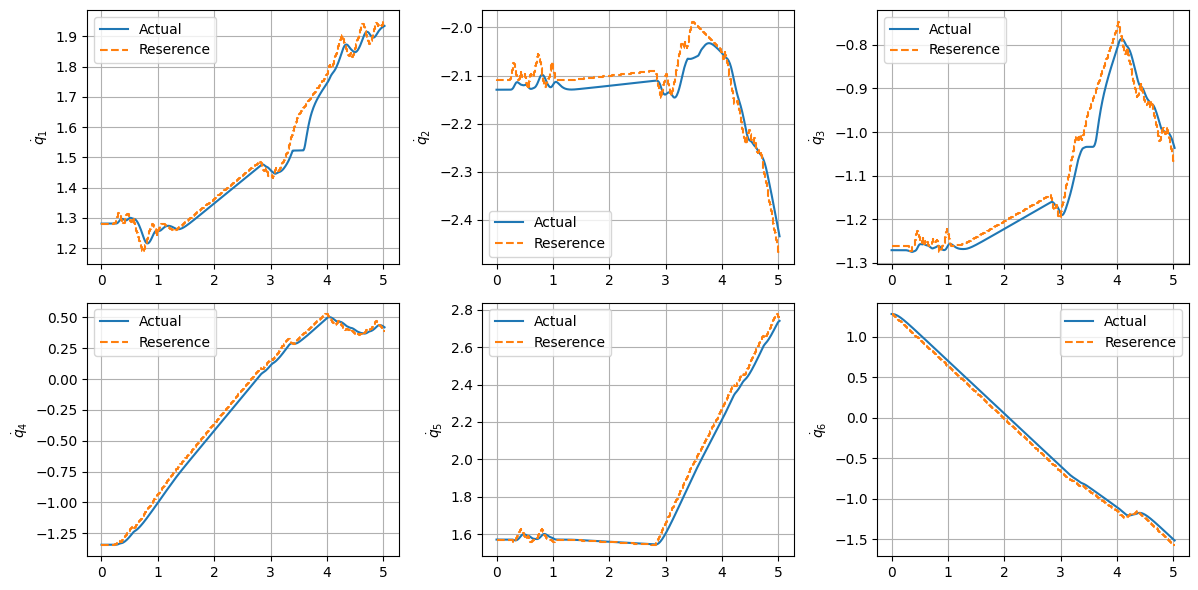

In [78]:
n = r.nj
cols = 3
rows = math.ceil(n / cols)
labs = ["x", "y", "z"]

fig, axes = plt.subplots(rows, cols, squeeze=False, figsize=(12, 6))

ax = axes.flatten()

for i in range(r.nj):
    ax[i].plot(tt, qt[:, i], "-", label="Actual")
    ax[i].plot(tt, rqt[:, i], "--", label="Reserence")
    ax[i].set_ylabel(f"$\\dot q_{i+1}$")
    ax[i].legend()
    ax[i].grid()

plt.tight_layout()
for a in ax[n:]:
    a.axis("off")

In [79]:
import mediapy
mediapy.show_video(frames, width=320, height=240)

This browser does not support the video tag.
